In [7]:
import numpy as np
import json
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import fisherz
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode
import time

X_pc_full_ea_cpd = np.load(r"C:\Users\user\Desktop\ai causal\FTND\european_american\cpd_pc_input.npy")
with open(r"C:\Users\user\Desktop\ai causal\FTND\european_american\cpd_pc_col_names.json") as f:
    col_names_ea_cpd = json.load(f)

n_nodes = len(col_names_ea_cpd)
outcome_idx = col_names_ea_cpd.index("CPD")
print("Input shape:", X_pc_full_ea_cpd.shape)
print("n_nodes:", n_nodes)

bk = BackgroundKnowledge()
nodes = [GraphNode(name) for name in col_names_ea_cpd]
for i in range(n_nodes - 1):
    bk.add_node_to_tier(nodes[i], 0)
bk.add_node_to_tier(nodes[outcome_idx], 1)

start = time.time()
cg = pc(
    data=X_pc_full_ea_cpd,
    alpha=0.001,
    indep_test=fisherz,
    stable=True,
    uc_rule=0,
    uc_priority=2,
    background_knowledge=bk,
    verbose=False,
    show_progress=True,
    node_names=col_names_ea_cpd
)
elapsed = time.time() - start
print(f"Completed in {elapsed:.1f}s")
print("Nodes:", len(cg.G.nodes))

Input shape: (863, 18)
n_nodes: 18


Depth=4, working on node 17: 100%|██████████| 18/18 [00:00<00:00, 1379.60it/s]


Completed in 0.3s
Nodes: 18


In [8]:
import networkx as nx
import pandas as pd
import re

adj = cg.G.graph
edges_directed_ea_cpd = []
edges_undirected_ea_cpd = []

for i in range(n_nodes):
    for j in range(i+1, n_nodes):
        if adj[i,j] == -1 and adj[j,i] == 1:
            edges_directed_ea_cpd.append((col_names_ea_cpd[i], col_names_ea_cpd[j]))
        elif adj[i,j] == 1 and adj[j,i] == -1:
            edges_directed_ea_cpd.append((col_names_ea_cpd[j], col_names_ea_cpd[i]))
        elif adj[i,j] == -1 and adj[j,i] == -1:
            edges_undirected_ea_cpd.append((col_names_ea_cpd[i], col_names_ea_cpd[j]))

print(f"Directed edges: {len(edges_directed_ea_cpd)}")
print(f"Undirected edges: {len(edges_undirected_ea_cpd)}")
print(f"Reverse edges (CPD → SNP): {len([(u,v) for u,v in edges_directed_ea_cpd if u=='CPD'])}")

print("\nEdges involving CPD:")
ea_cpd_snps = []
for u, v in edges_directed_ea_cpd:
    if v == "CPD":
        print(f"  {u} → CPD")
        ea_cpd_snps.append(u)
for u, v in edges_undirected_ea_cpd:
    if "CPD" in (u, v):
        other = v if u == "CPD" else u
        print(f"  {other} --- CPD (undirected)")
        ea_cpd_snps.append(other)

print(f"\nTotal SNPs connected to CPD: {len(ea_cpd_snps)}")

# ancestral subgraph
G_ea_cpd = nx.DiGraph()
G_ea_cpd.add_nodes_from(col_names_ea_cpd)
for u, v in edges_directed_ea_cpd:
    G_ea_cpd.add_edge(u, v)
G_reach = G_ea_cpd.copy()
for u, v in edges_undirected_ea_cpd:
    G_reach.add_edge(u, v)
    G_reach.add_edge(v, u)

ancestors = nx.ancestors(G_reach, "CPD")
ancestors.add("CPD")
print(f"Ancestral subgraph nodes: {len(ancestors)}")

Directed edges: 20
Undirected edges: 1
Reverse edges (CPD → SNP): 0

Edges involving CPD:
  exm24035-0_B_R_1921346506 → CPD
  exm1614640-0_T_R_1919086982 → CPD
  exm659391-0_B_R_1918526444 → CPD
  exm776310-0_B_R_1922396242 → CPD

Total SNPs connected to CPD: 4
Ancestral subgraph nodes: 5


Annotating EA CPD network SNPs...
  Chr1:17,982,446 → ARHGEF10L
  Chr22:43,218,397 → ARFGAP3 | PACSIN2
  Chr7:134,617,884 → CALD1
  Chr9:119,028,233 → PAPPA


C:\Users\user\AppData\Local\Temp\ipykernel_33876\1272722704.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_chroms))


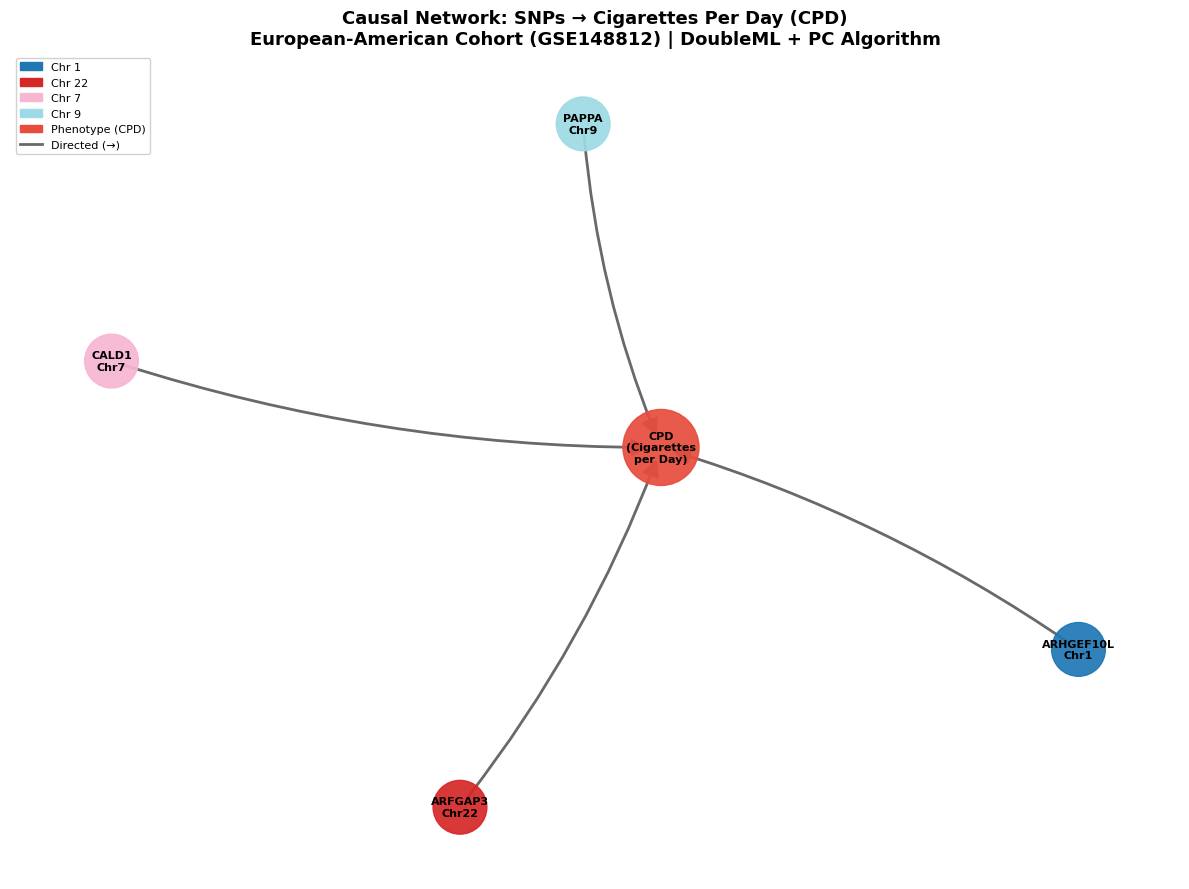

Saved: C:\Users\user\Desktop\ai causal\FTND\european_american\cpd_causal_network_EA.png


In [9]:
import requests
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np

MANIFEST = r"C:\Users\user\Downloads\HumanExome-12-v1-0-B.csv"
manifest_df = pd.read_csv(MANIFEST, skiprows=7, low_memory=False)
manifest_df["core_name"] = manifest_df["IlmnID"].map(lambda x: re.sub(r'_\d+$', '', x))
chr_lookup = manifest_df.set_index("core_name")["Chr"]
pos_lookup_m = manifest_df.set_index("core_name")["MapInfo"]

def get_chr(pid):
    if pid == "CPD": return "phenotype"
    return str(chr_lookup.get(re.sub(r'_\d+$', '', pid), "?"))

def get_pos(pid):
    val = pos_lookup_m.get(re.sub(r'_\d+$', '', pid), None)
    return int(val) if pd.notna(val) else None

def get_gene_ensembl(chrom, pos, window=50000):
    url = f"https://grch37.rest.ensembl.org/overlap/region/human/{chrom}:{pos-window}-{pos+window}"
    params = {"feature": "gene", "content-type": "application/json"}
    try:
        r = requests.get(url, params=params, timeout=15)
        if r.status_code != 200: return "?"
        genes = r.json()
        if not genes: return "intergenic"
        coding = [g for g in genes if g.get("biotype") == "protein_coding"]
        targets = coding if coding else genes
        names = list(set(g.get("external_name", "?") for g in targets))
        return " | ".join(names[:3])
    except: return "error"

print("Annotating EA CPD network SNPs...")
gene_map_ea_cpd = {}
for pid in ea_cpd_snps:
    chrom = get_chr(pid)
    pos = get_pos(pid)
    gene = get_gene_ensembl(chrom, pos)
    gene_map_ea_cpd[pid] = gene
    print(f"  Chr{chrom}:{pos:,} → {gene}")
    time.sleep(0.5)

# build final graph
G_final_ea_cpd = nx.DiGraph()
G_final_ea_cpd.add_nodes_from(ancestors)

directed_draw = [(u,v) for u,v in edges_directed_ea_cpd if u in ancestors and v in ancestors]
undirected_draw = []
undirected_pairs = set()
for u,v in edges_undirected_ea_cpd:
    if u in ancestors and v in ancestors and (v,u) not in undirected_pairs:
        undirected_pairs.add((u,v))
        undirected_draw.append((u,v))
        G_final_ea_cpd.add_edge(u,v,undirected=True)
        G_final_ea_cpd.add_edge(v,u,undirected=True)
for u,v in directed_draw:
    G_final_ea_cpd.add_edge(u,v)

# colors
unique_chroms = sorted(set(get_chr(n) for n in G_final_ea_cpd.nodes() if n != "CPD"))
cmap = plt.cm.get_cmap("tab20", len(unique_chroms))
chrom_color = {c: cmap(i) for i, c in enumerate(unique_chroms)}
chrom_color["phenotype"] = "#e74c3c"

def make_label(pid):
    if pid == "CPD": return "CPD\n(Cigarettes\nper Day)"
    gene = gene_map_ea_cpd.get(pid, "")
    chrom = get_chr(pid)
    if gene and gene not in ["intergenic","?","error"]:
        return f"{gene.split('|')[0].strip()}\nChr{chrom}"
    return f"Chr{chrom}\n{pid.split('-')[0]}"

node_colors = [chrom_color[get_chr(n)] for n in G_final_ea_cpd.nodes()]
node_sizes = [3000 if n == "CPD" else 1500 for n in G_final_ea_cpd.nodes()]
node_labels = {n: make_label(n) for n in G_final_ea_cpd.nodes()}

pos = nx.spring_layout(G_final_ea_cpd, seed=42, k=3.0)
pos["CPD"] = np.array([0.0, 0.0])
for node in pos:
    if node != "CPD":
        vec = pos[node] - np.array([0.0, 0.0])
        dist = np.linalg.norm(vec)
        if dist < 0.4:
            pos[node] = np.array([0.0, 0.0]) + (vec/dist) * 0.4

plt.figure(figsize=(12, 9))
nx.draw_networkx_nodes(G_final_ea_cpd, pos, node_color=node_colors,
                       node_size=node_sizes, alpha=0.92)
nx.draw_networkx_labels(G_final_ea_cpd, pos, labels=node_labels,
                        font_size=8, font_weight="bold")
nx.draw_networkx_edges(G_final_ea_cpd, pos, edgelist=directed_draw,
                       edge_color="dimgray", arrows=True,
                       arrowsize=25, width=2.0,
                       connectionstyle="arc3,rad=0.08")
nx.draw_networkx_edges(G_final_ea_cpd, pos, edgelist=undirected_draw,
                       edge_color="steelblue", arrows=False,
                       style="dashed", width=1.5)

legend_patches = [mpatches.Patch(color=chrom_color[c], label=f"Chr {c}")
                  for c in unique_chroms]
legend_patches.append(mpatches.Patch(color="#e74c3c", label="Phenotype (CPD)"))
legend_patches.append(plt.Line2D([0],[0], color="dimgray", linewidth=2, label="Directed (→)"))
plt.legend(handles=legend_patches, loc="upper left", fontsize=8, framealpha=0.9)

plt.title("Causal Network: SNPs → Cigarettes Per Day (CPD)\n"
          "European-American Cohort (GSE148812) | DoubleML + PC Algorithm",
          fontsize=13, fontweight="bold")
plt.axis("off")
plt.tight_layout()

out_path = r"C:\Users\user\Desktop\ai causal\FTND\european_american\cpd_causal_network_EA.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out_path)